# Building an Autograd Engine from Scratch with CuPy: Part 1 - Tensor and Backpropagation

In this series, we are going to build a complete autograd engine from scratch and then use it to build a transformer. No Pytorch or Jax, just pure python and CuPy(Numpy if you don't have GPU). The goal is to deeply understand how automatic differentiation works. This will give us true intuition of what is happening under the hood when we call `loss.backward()` to train our models.

This is part 1, where we build the core `Tensor` class with full backpropagation support. By end of this post, we will train a linear regression model using our own autograd, and we will verify it using numerical gradient checking.

## Why build this?
1. **Understanding**: Calling `loss.backward()` in PyTorch is literally magic until we build it ourselves. Here we will understand how it comes together with chain rule, topological sort, and gradient accumulation.

2. **CuPy as backend**: CuPy mirrors the NumPy API almost perfectly but runs on GPU. By building on CuPy, we get GPU accelaration for free without writing any CUDA code. In absence of GPU, the same code falls back to NumPy with zero changes. Although, our goal is not performance, but understanding how things work under the hood. CuPy also does all the linear algebra under the hood so we can focus on understanding autograd cleanly.

## Computation Graphs and the Chain Rule
The core idea behind automatic differentiation is simple, every computation is a sequence of simple elementary operations (add, multiply, exp ect), and we know derivative of each one. The chain rule then helps us compose them. When we write:

```python
c = a * b
d = c.sum()
```
We are actually implicitly building a computation graph (a directed acyclic graph, or DAG):

```mermaid
graph TB
    a["a"] --> mul["c = a * b"]
    b["b"] --> mul
    mul --> sum["d = c.sum()"]

    style a fill:#4A90D9,stroke:#2C5F8A,color:#fff,stroke-width:2px
    style b fill:#4A90D9,stroke:#2C5F8A,color:#fff,stroke-width:2px
    style mul fill:#7CB342,stroke:#558B2F,color:#fff,stroke-width:2px
    style sum fill:#FF7043,stroke:#D84315,color:#fff,stroke-width:2px
```

```text
    a    b
    │    │
    └─*──┘
      │
      c
      │
     sum
      │
      d
```

Each node knows:

- **What operation created it?** (multiply, sum etc)
- **Which tensors were it's input?** (it's *parents*)
- **How to push gradients back to it's parents?** (the local derivative)

`backward()` walks the graph in reverse from the loss back to the parameters, and apply the chain rule at each step. This is a reverse-mode automatic differentiation and is the magic sauce of training a neural network at scale.

## Backend: CPU/GPU Switching

Before we build the `Tensor`, let's setup a tiny backend module. We'll import `xp` which will be aliased to either `numpy` or `cupy` depending on what's available

In [7]:
!pip install -q cupy-cuda12x   #

In [8]:
"""
cutigrad/backend.py
"""
import os

_requested = os.environ.get("CUTIGRAD_BACKEND", "auto").lower()

if _requested == "cupy":
  import cupy as xp
elif _requested == "numpy":
  import numpy as xp
else:
  try:
    import cupy as xp
    xp.array([0])
  except Exception:
    import numpy as xp

BACKEND_NAME = xp.__name__  # "numpy" or "cupy"

def to_numpy(arr):
  """Convert and arry to numpy"""
  if BACKEND_NAME == "cupy":
    return arr.get()
  return arr



Set `CUTIGRAD_BACKEND=cupy` to force GPU, `CUTIGRAD_BACKEND=numpy` to force CPU, or leave it as auto.

## The Tensor Class

Now, we will build the `Tensor` class which wraps an `xp.ndarray` and adds the three things:

1. `requires_grad`: Should we track operations on this tensor? This is usually true for a trainable parameter.

2. `_parents`: THe tensors which were inputs to the operation that created this tensor.

3. `_grad_fn`: A closure that, given the upstream gradient, pushes gradients to the parents.

```python
"""
cutigrad/tensor.py - A tensor class with auto-differentiation
"""

from typing import List, Optional, Union, Callable
from cutigrad.backend import xp, to_numpy
import numpy as np

class Tensor:
  def __init__(self, data, requires_grad: bool = False):
    if isinstance(data, xp.ndarray):
      self.data = data
    elif isinstance(data, np.ndarray):
      self.data = xp.array(data)
    else:
      self.data = xp.array(data, dtype=xp.float64)
    
    self.grad: Optional[xp.ndarray] = None
    self._grad_fn: Optional[Callable] = None
    self._parents: List[Tensor] = []
```

In [11]:
"""
cutigrad/tensor.py - A tensor class with auto-differentiation
"""

from typing import List, Optional, Union, Callable
#from cutigrad.backend import xp, to_numpy
import numpy as np

class Tensor:
  def __init__(self, data, requires_grad: bool = False):
    if isinstance(data, xp.ndarray):
      self.data = data
    elif isinstance(data, np.ndarray):
      self.data = xp.array(data)
    else:
      self.data = xp.array(data, dtype=xp.float64)

    self.grad: Optional[xp.ndarray] = None
    self._grad_fn: Optional[Callable] = None
    self._parents: List[Tensor] = []

Pretty straightforward so far. The `data` stored is an `xp.ndarray` and we have slots for the gradient and graph metdata. Now, let's add some more properties

```python

```

In [12]:
@property
def shape(self) -> tuple:
  return self.data.shape

@property
def dtype(self):
  return self.data.dtype

@property
def ndim(self) -> int:
  return self.data.ndim

@property
def T(self) -> Tensor:
  return self.transpose()

def numpy(self):
  """Return data as numpy array (moves off GPU if needed)"""
  return to_numpy(self.data)

def zero_grad(self):
  self.grad = None

def detach(self):
  """Returns a new Tensor sharing data but detached from graph"""
  return Tensor(self.data, requires_grad=False)

def __repr__(self):
  grad_info = ", requires_grad=True" if self.requires_grad else ""
  return f"Tensor{to_numpy(self.data)}{grad_info}"




## The Backward Pass

This is the core of everything we are trying to do. The main idea is:

1. Start from the loss tensor with gradient = 1 (since $\frac{\partial L}{\partial L} = 1$).
2. **Topologically sort the computation graph.
3. Walk in **reverse** topological order. At each node, call it's `_grad_fn` to push gradients to it's parents.

### Why do we need to sort topologically?

Consider a tensor `x` that feeds into both `y1` and `y2` which feed into `z`. We need both $\frac{\partial z}{\partial y_1}$$ and $$\frac{\partial z}{\partial y_2}$ accumulated at $x$ before we can propagate further back. Reverse topological order guarantees this, as we will always process a node only after all it's consumers have been processed.

```mermaid
graph TB
    x["x<br/><span style='font-size:12px; color:#666'>requires_grad=True</span>"]
    y1["y₁ = f(x)"]
    y2["y₂ = g(x)"]
    z["z = h(y₁, y₂)"]

    x --> y1
    x --> y2
    y1 --> z
    y2 --> z

    style x fill:#4A90D9,stroke:#2C5F8A,color:#fff,stroke-width:2px
    style y1 fill:#7CB342,stroke:#558B2F,color:#fff,stroke-width:2px
    style y2 fill:#7CB342,stroke:#558B2F,color:#fff,stroke-width:2px
    style z fill:#FF7043,stroke:#D84315,color:#fff,stroke-width:2px
```

The gradient of z with respect to x flows through two paths: one via y₁ and one via y₂. We need both $$\frac{\partial z}{\partial y_1} \cdot \frac{\partial y_1}{\partial x}$$ and $$\frac{\partial z}{\partial y_2} \cdot \frac{\partial y_2}{\partial x}$$ accumulated at x before we can propagate any further back.
Reverse topological order guarantees this. We always process a node only after all its consumers have already pushed their gradients to it. Here's what that looks like step by step:

```mermaid
graph BT
    z["Step 1: Start at z<br/>grad_z = 1"]
    y1["Step 2: Process y₁<br/>grad_y₁ = ∂z/∂y₁ · grad_z"]
    y2["Step 3: Process y₂<br/>grad_y₂ = ∂z/∂y₂ · grad_z"]
    x["Step 4: Process x (LAST)<br/><br/>grad_x = ∂y₁/∂x · grad_y₁<br/>         + ∂y₂/∂x · grad_y₂<br/><br/>Both contributions accumulated!"]

    z --> y1
    z --> y2
    y1 --> x
    y2 --> x

    style z fill:#FF7043,stroke:#D84315,color:#fff,stroke-width:2px
    style y1 fill:#7CB342,stroke:#558B2F,color:#fff,stroke-width:2px
    style y2 fill:#7CB342,stroke:#558B2F,color:#fff,stroke-width:2px
    style x fill:#4A90D9,stroke:#2C5F8A,color:#fff,stroke-width:2px
```

If we processed x before y₂ was done, we'd miss half the gradient. Topological sort prevents this.

### Implementation

In [2]:
def backward(self, grad: Optional[xp.ndarray] = None):
  if not self.requires_grad:
    raise RuntimeError(
        "backward() called on a tensor that doesn't require grad"
    )

  # seed gradient
  if grad is None:
    if self.data_size != 1:
      raise RuntimeError(
          f"backward() without a gradient argument is only valida for scaler tensor, got shape: {self.shape}"
      )
    grad = xp.ones_like(self.data)

  # Step 1: Topological sort via DFS
  topo_order: List[Tensor] = []
  visited = set()

  def _build_topo(tensor: Tensor):
    if id(tensor) not in visited:
      visited.add(id(tensor))
      for parent in tensor._parents:
        _build_topo(parent)
      topo_order.append(tensor)

  _build_topo(self)

  # Step 2: Reverse walk — propagate gradients
  self.grad = grad
  for tensor in reversed(topo_order):
    if tensor._grad_fn is not None:
      tensor._grad_fn(tensor.grad)

NameError: name 'Optional' is not defined

 The entire backward pass is a topological sort followed by a reverse walk. Each `_grad_fn` knows how to compute the local gradient and accumulate it into its parents' `.grad`. This will become more clear when we show a backpropagation.

 Now, let's implement some operations.

 ## Implementing Operations

 Each operation:
 1. Computes the forward pass (the actual math).
 2. Creates an output `Tensor` with `_parents` and `_grad_fn` set.
 3. The `_grad_fn` closure captures everything it needs to compute the local gradient.

The key idea is the chain rule: to compute how a parameter affects the loss, we multiply the upstream gradient (how much the output affects the loss) by the local derivative (how much the input affects the output):

$$
\frac{\partial L}{\partial \text{input}} = \underbrace{\frac{\partial L}{\partial \text{out}}}_{\text{upstream gradient}} \cdot \underbrace{\frac{\partial \text{out}}{\partial \text{input}}}_{\text{local derivative}}
$$

 ### Addition

 $$\text{out} = a + b$$

 The gradient of addition with respect to both inputs is 1. So the upstream gradient just passes through.

 $$
 \frac{\partial L}{\partial a} = \frac{\partial L}{\partial \text{out}}.1
 $$

In [3]:
def add(self, other: Union[Tensor, float, int]) -> Tensor:
  other = _ensure_tensor(other) # not here for terseness, check code on github
  out_data = self.data + other.data
  out = Tensor(out_data,
               requires_grad=self.requires_grad or other.requires_grad)

  if out.requires_grad:
    out._parents = [self, other]

    def _backward(grad_output):
      if self.requires_grad:
        g = _unbroadcast(grad_output, self.shape)
        self.grad = self.grad +  g if self.grad is not None else g
      if other.requires_grad:
        other.grad = other.grad + g if other.grad is not None else g

    out._grad_fn = _backward

  return out

NameError: name 'Union' is not defined

Notice two things:

1. **Gradient accumulation**: We do `self.grad = self.grad + g` not `self.grad = g`. This is critical for shared nodes (more on this below).

2. **`_unbroadcast`**: This handles broadcasting, we will explore this too in a moment.

### Multiplication

$$
\text{out} = a \times b
$$

By the product rule:

$$
\frac{\partial L}{\partial a} = \frac{\partial L}{\partial \text{out}}.b
$$

$$
\frac{\partial L}{\partial b} = \frac{\partial L}{\partial \text{out}}.a
$$

Remember, here `out` feeds into some larger computation in the graph that evetually produces a loss $L$. By the time backward pass reaches `out`, we already know $\frac{\partial L}{\partial \text{out}}$. This is the upstream gradient.

Say we have $a = 3$, $b = 4$, so $\text{out} = 12$. And suppose `out` feeds into some larger computation that eventually produces a loss $L$. By the time the backward pass reaches `out`, we already know $\frac{\partial L}{\partial \text{out}}$ — that's the **upstream gradient**. Let's say it's 2.0 for this example.

Now we need: what's $\frac{\partial L}{\partial a}$?

**The chain rule says**: multiply the upstream gradient by the local derivative:

$$\frac{\partial L}{\partial a} = \frac{\partial L}{\partial \text{out}} \cdot \frac{\partial \text{out}}{\partial a}$$

**The local derivative** of $\text{out} = a \times b$ with respect to $a$ is just $b$. Think about it: if we hold $b$ constant at 4 and nudge $a$ by a tiny amount $\epsilon$, the output changes by $b \cdot \epsilon = 4\epsilon$. So:

$$\frac{\partial \text{out}}{\partial a} = b = 4$$

Putting it together:

$$\frac{\partial L}{\partial a} = 2.0 \times 4 = 8.0$$

And symmetrically for $b$:

$$\frac{\partial L}{\partial b} = \frac{\partial L}{\partial \text{out}} \cdot a = 2.0 \times 3 = 6.0$$

```mermaid
graph LR
    subgraph FWD["Forward"]
        direction LR
        a_f["a = 3"] --> mul_f["out = a × b = 12"]
        b_f["b = 4"] --> mul_f
        mul_f --> loss_f["... → L"]
    end

    subgraph BWD["Backward"]
        direction RL
        loss_b["upstream grad = 2.0"] --> mul_b["mul backward"]
        mul_b -->|"grad × b = 2.0 × 4 = 8.0"| a_b["∂L/∂a = 8.0"]
        mul_b -->|"grad × a = 2.0 × 3 = 6.0"| b_b["∂L/∂b = 6.0"]
    end

    style a_f fill:#4A90D9,stroke:#2C5F8A,color:#fff
    style b_f fill:#4A90D9,stroke:#2C5F8A,color:#fff
    style mul_f fill:#7CB342,stroke:#558B2F,color:#fff
    style loss_f fill:#FF7043,stroke:#D84315,color:#fff
    style loss_b fill:#FF7043,stroke:#D84315,color:#fff
    style mul_b fill:#7CB342,stroke:#558B2F,color:#fff
    style a_b fill:#4A90D9,stroke:#2C5F8A,color:#fff
    style b_b fill:#4A90D9,stroke:#2C5F8A,color:#fff
```

The intuition: to find how much $a$ affects the loss, ask "if I nudge $a$, how much does $\text{out}$ change?" That's $b$. Then multiply by how much
$out$ affects the loss (the upstream gradient). It's the chain rule applied one link at a time.


In [4]:
def mul(self, other: Union[Tensor, float, int]) -> Tensor:
  other = _ensure_tensor(other)
  out_data = self.data * other.data
  out = Tensor(out_data,
               requires_grad=self.requires_grad or other.requires_grad)
  if out.requires_grad:
    out._parents = [self, other]

    def _backward(grad_output):
      if self.requires_grad:
        g = _unbroadcast(grad_output * other.data, self.shape)
        self.grad = self.grad + g if self.grad is not None else g
      if other.requires_grad:
        g = _unbroadcast(grad_output * self.data, other.shape)
        other.grad = other.grad + g if other.grad is not None else g

    out._grad_fn = _backward
  return out


NameError: name 'Union' is not defined

Note that every operation we implement follows almost exactly same pattern: Compute the local derivative, multiply by the upstream gradient and accumulate.

### Matrix Multiplication

$$
C = A @ B
$$

The gradient derivation for matmul is a bit more involved:

$$
\frac{\partial L}{\partial A} = \frac{\partial L}{\partial C} \cdot B^T \qquad \frac{\partial L}{\partial B} = A^T \cdot \frac{\partial L}{\partial C}
$$

Remember, the shapes of the matrices need to work out.  If $A$ is $(m, n)$ and $B$ is $(n, p)$, then $C$ is $(m, p)$. The gradient $\frac{\partial L}{\partial A}$ must be $(m, n)$, and the only way to get that from a $(m, p)$ gradient and a $(n, p)$ matrix is $(m, p) @ (p, n) = (m, n)$ which is $\text{grad} @ B^T$.

In [ ]:
def matmul(self, other: Tensor) -> Tensor:
  out_data = self.data @ other.data
  out = Tensor(
      out_data,
      requires_grad=self.requires_grad or other.requires_grad
  )

  if out.requires_grad:
    out._parents = [self, other]

    def _backward(grad_output):
      if self.requires_grad:
        if other.data.ndim == 1:
          g = xp.outer(grad_output, other.data)
        else:
          g = grad_output @ xp.swapaxes(other.data, -1, -2)
        g = _unbroadcast(g, self.shape)
        self.grad = self.grad + g if self.grad is not None else g

      if other.requires_grad:
        if self.data.ndim == 1:
          g = xp.outer(self.data, grad_output)
        else:
          g = xp.swapaxes(self.data, -1, -2) @ grad_output
        g = _unbroadcast(g, other.shape)
        other.grad = other.grad + g if other.grad is not None else g

    out._grad_fn = _backward

  return out


### More Operations

We can also write other operations similarly. The class code in github contains `pow`, `exp`, `log`, `sum`, `mean`, `max`, `reshape` and `transpose` and indexing. Each one does the forward math, then sets `_parents` and `_grad_fn` on the output. The key gradient formulas are

| Operation | Forward | Local Derivative |
|-----------| --------| -----------------|
| `pow(n)`  | $x^n$   | $n.x^{n-1}$ |
| `exp`     | $e^x$   | $e^x$ |
| `log`     | $ln(x)$ | $\frac{1}{x}$ |
| `sum`     | $\sum{x_i}$| broadcast upstream gradient back to input shape|
| `reshape` | shape change | reshape gradient back to original shape|
| `transpose` | axis swap | swap axes back |


Here is `exp` and `log` as examples:


In [ ]:
def exp(self) -> Tensor:
  out_data = xp.exp(self.data)
  out = Tensor(out_data, requires_grad=self.requires_grad)

  if out.requires_grad:
    out._parents = [self]

    def _backward(grad_output):
      g = grad_output * out_data
      self.grad = self.grad + g if self.grad is not None else g

    out._grad_fn = _backward

  return out

In [ ]:
def log(self) -> Tensor:
  out_data = xp.log(self.data)
  out = Tensor(out_data, requires_grad=self.requires_grad)

  if out.requires_grad:
    out._parents = [self]

    def _backward(grad_output):
      g = grad_output / self.data
      self.grad = self.grad + g if self.grad is not None else g

    out._grad_fn = _backward

  return out

And we add Python operator overloads so we can write natural math:

In [ ]:
def __add__(self, other):      return self.add(other)
def __radd__(self, other):     return _ensure_tensor(other).add(self)
def __mul__(self, other):      return self.mul(other)
def __rmul__(self, other):     return _ensure_tensor(other).mul(self)
def __sub__(self, other):      return self.sub(other)
def __neg__(self, other):      return self.neg()
def __matmul__(self, other):   return self.matmul(other)
def __pow__(self, exp):        return self.pow(exp)
def __truediv__(self, other):  return self.div(other)


## Note on `_unbroadcast`

When we are applying operations on tensors of different but compatible shapes, we often need to handle these subtle case of mismatches.

Say we are trying to compute $a + b$ where $a$ has shape $(3, 2)$ and $b$ has shape $(2,)$, the NumPy will broadcast $b$ along axis 0. The output will have shape $(3, 2)$, and therefore the gradient flowing back will also have shape $(3, 2)$. However $b$ only has shape $(2,)$. We need to sum over the broadcast dimension (axis 0) to get the gradient back to $b$'s shape:

$$\frac{\partial L}{\partial b_j} = \sum_{i=0}^{2} \frac{\partial L}{\partial \text{out}_{ij}}$$


 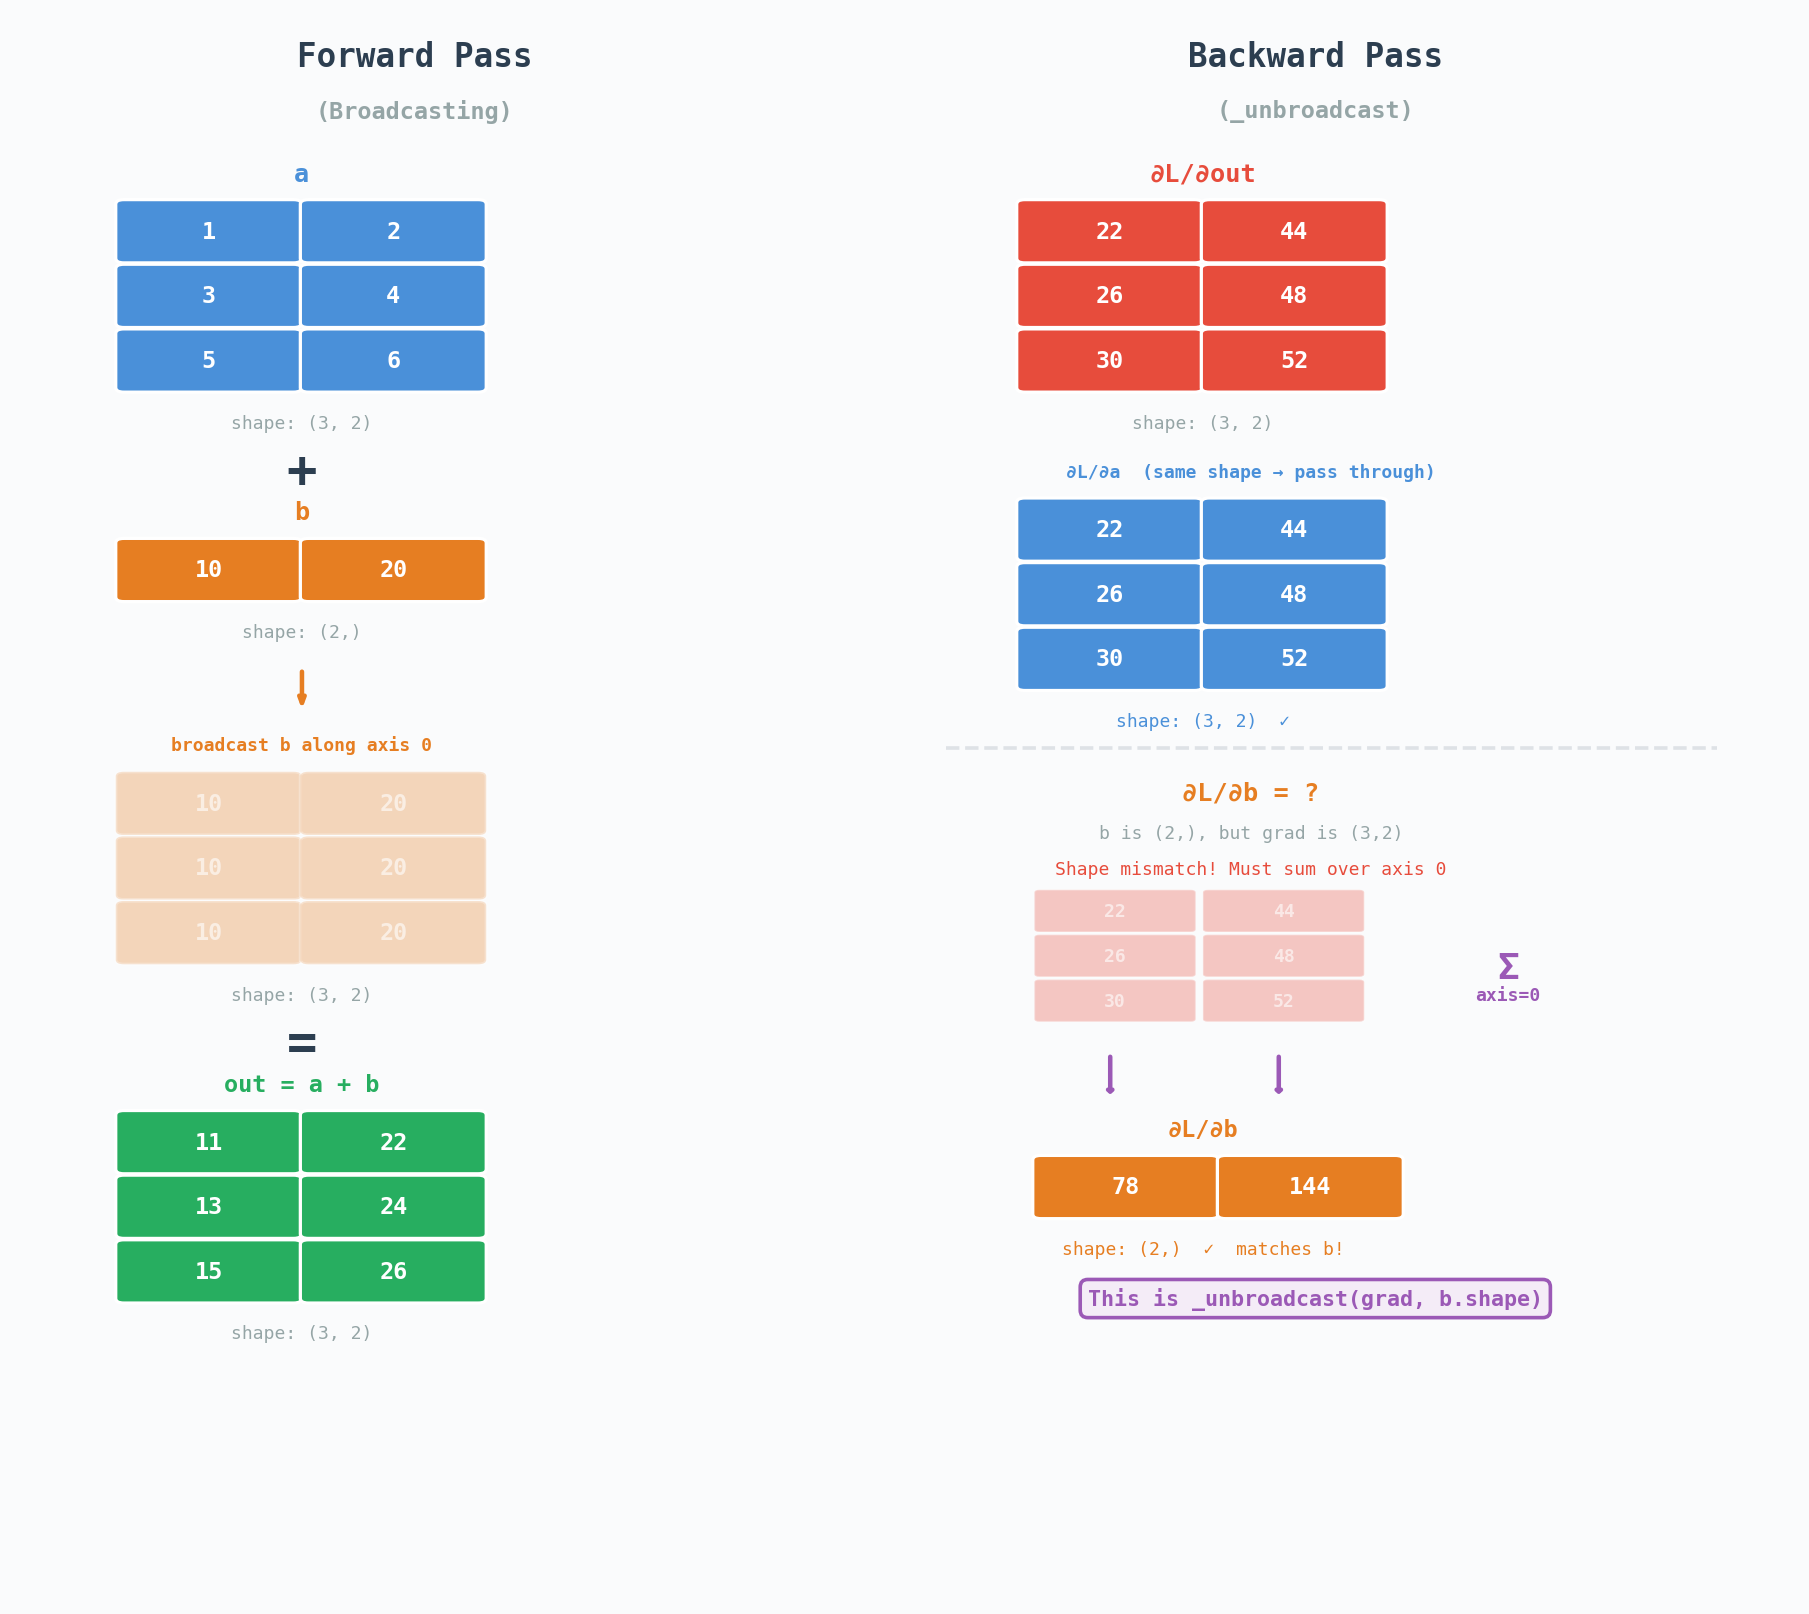

This is what `_unbroadcast` does. Note that PyTorch handles this deep inside its C++ backend (ATen). Here we are doing it in python to make the concept more clear.

In [1]:
def _unbroadcast(grad, target_shape):
  """
  Reduce grad back to target_shape by summing over broadcast dimensions.
  """
  if grad.shape == target_shape:
    return grad

  # Pad target_shape with leading 1s to match grid's dim
  ndim_diff = grad.ndim - len(target_shape)
  padded_shape = (1, ) * ndim_diff + target_shape

  # Sum over the axes that were broadcast
  reduce_axes = []
  for i, (gs, ts) in enumerate(zip(grad.shape, padded_shape)):
    if ts == 1 and gs > 1:
      reduce_axes.append(i)
    elif ts == 1 and gs == 1 and i < ndim_diff:
      reduce_axes.append(i)

  if reduce_axes:
    grad = grad.sum(axia=tuple(reduce_axes), keepdims=True)

  return grad.reshape(target_shape)

## Special Note about the Shared Node

Consider:

```python
x = Tensor([3.0], requires_grad=True)
y = x * x
loss = y.sum()
loss.backward()
```

What should `x.grad` be? Since $y=x^2$, we expect $\frac{\partial y}{\partial x} = 2x = 6.0$

But look at what is happening in the computation graph. $x$ appears twice as both left and right inputs to `mul`.

```mermaid
graph TB
    subgraph FWD["Forward Pass"]
        direction TB
        x_f["x = 3.0"]
        mul_f["y = x × x = 9.0"]
        sum_f["loss = y.sum() = 9.0"]

        x_f -->|"left input"| mul_f
        x_f -->|"right input"| mul_f
        mul_f --> sum_f
    end

    subgraph BWD["Backward Pass"]
        direction BT
        sum_b["Step 1: grad_loss = 1.0"]
        mul_b["Step 2: grad_y = 1.0"]
        x_b["Step 3: grad_x<br/>= right × grad_y + left × grad_y<br/>= 3.0 × 1.0 + 3.0 × 1.0<br/>= 6.0 ✓"]

        sum_b --> mul_b
        mul_b -->|"∂(x·x)/∂left = right = 3.0"| x_b
        mul_b -->|"∂(x·x)/∂right = left = 3.0"| x_b
    end

    style x_f fill:#4A90D9,stroke:#2C5F8A,color:#fff,stroke-width:2px
    style mul_f fill:#7CB342,stroke:#558B2F,color:#fff,stroke-width:2px
    style sum_f fill:#FF7043,stroke:#D84315,color:#fff,stroke-width:2px
    style sum_b fill:#FF7043,stroke:#D84315,color:#fff,stroke-width:2px
    style mul_b fill:#7CB342,stroke:#558B2F,color:#fff,stroke-width:2px
    style x_b fill:#4A90D9,stroke:#2C5F8A,color:#fff,stroke-width:2px
```

When `mul`'s `_backward` runs, it pushes two gradients to x:

From the left input: $$\frac{\partial L}{\partial \text{out}} \times \text{right} = 1.0 \times 3.0 = 3.0$$
From the right input: $$\frac{\partial L}{\partial \text{out}} \times \text{left} = 1.0 \times 3.0 = 3.0$$

These accumulate to give $3.0+3.0=6.0$, which is exactly $2x=2\times3=6.0$. So if we had `self.grad = g` instead of `self.grad = self.grad + g`, we would have overwritten the first contribution with second and gotten $3.0$ instead of $6.0$. That is why every `_backward` function does:

```python
self.grad = self.grad + g if self.grad is not None else g
```

And this is why topological sort matters. It ensures both gradient contributions arrive at $x$ before we try to propagate any further.

## Verifying Correctness: Numerical Gradient Checking

How do we know our gradients are correct? We will compare them against the numerical gradients computed via finite difference method.

